# bar
> Categorical, count, distribution, and composition plot helpers.

In [ ]:
#| default_exp bar

In [ ]:
#| export
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from fastcore.meta import delegates
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator

from kplot.utils import add_stats, get_plt_color

In [ ]:
df = sns.load_dataset('tips').dropna()
df.shape

(244, 7)

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Distribution Plots

In [ ]:
#| export
@delegates(sns.histplot)
def plot_hist(
    df: pd.DataFrame,  # dataframe containing the values to plot
    x: str,  # numeric column name
    figsize: tuple[float, float] = (6, 2),  # figure size in inches
    **kwargs,  # forwarded histplot kwargs
):
    "Plot a histogram with a KDE overlay and polygon bins." 
    hist_params = {'element': 'poly', 'edgecolor': None, 'alpha': 0.5, 'bins': 100, 'kde': True}
    hist_params.update(kwargs)
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=x, ax=ax, **hist_params)
    return ax

<Axes: xlabel='total_bill', ylabel='Count'>

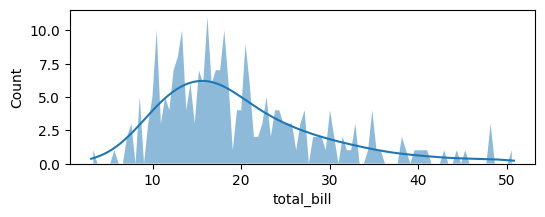

In [ ]:
plot_hist(df, 'total_bill')

## Count And Bar Plots

In [ ]:
#| export
def plot_count(
    cnt: pd.Series,  # output of df[col].value_counts()
    tick_spacing: float | None = None,  # optional major tick interval
    palette: str = 'tab20',  # seaborn palette name
):
    "Plot horizontal counts from a value-count series." 
    cnt = cnt.sort_values(ascending=True).copy()
    fig, ax = plt.subplots(figsize=(6, 3))
    cnt.plot.barh(color=sns.color_palette(palette), ax=ax)
    ax.set_ylabel('')
    for index, value in enumerate(cnt):
        ax.text(value, index, str(value), fontsize=10, rotation=-90, va='center')
    if tick_spacing is not None:
        ax.xaxis.set_major_locator(MultipleLocator(tick_spacing))
    return ax

<Axes: >

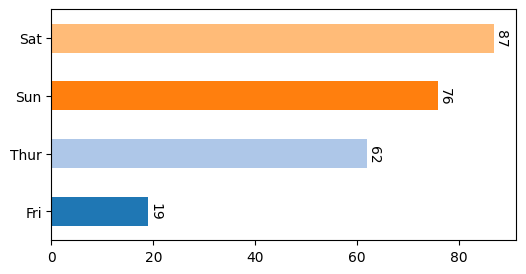

In [ ]:
plot_count(df['day'].value_counts())

In [ ]:
#| export
@delegates(sns.barplot)
def plot_bar(
    df: pd.DataFrame,  # long-form dataframe
    value: str,  # numeric column name
    group: str,  # grouping column name
    title: str | None = None,  # optional plot title
    figsize: tuple[float, float] = (12, 5),  # figure size in inches
    fontsize: int = 14,  # axis label and tick size
    dots: bool = True,  # whether to overlay strip dots
    rotation: float = 90,  # x tick rotation angle
    ascending: bool = False,  # sort group means ascending when True
    ymin: float | None = None,  # optional lower y-axis bound
    **kwargs,  # forwarded barplot kwargs
):
    "Plot a bar chart from an unstacked dataframe." 
    fig, ax = plt.subplots(figsize=figsize)
    idx = df.groupby(group)[value].mean().sort_values(ascending=ascending).index
    sns.barplot(data=df, x=group, y=value, order=idx, hue=group, dodge=False, legend=False, ax=ax, **kwargs)

    if dots:
        marker = {'marker': 'o', 'color': 'white', 'edgecolor': 'black', 'linewidth': 1.5, 'jitter': True, 's': 5}
        sns.stripplot(data=df, x=group, y=value, order=idx, alpha=0.8, ax=ax, **marker)

    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_xlabel('')
    ax.set_ylabel(value, fontsize=fontsize)
    plt.xticks(rotation=rotation)
    if title is not None:
        plt.title(title, fontsize=fontsize)
    if ymin is not None:
        plt.ylim(bottom=ymin)
    ax.spines[['right', 'top']].set_visible(False)
    return ax

<Axes: ylabel='total_bill'>

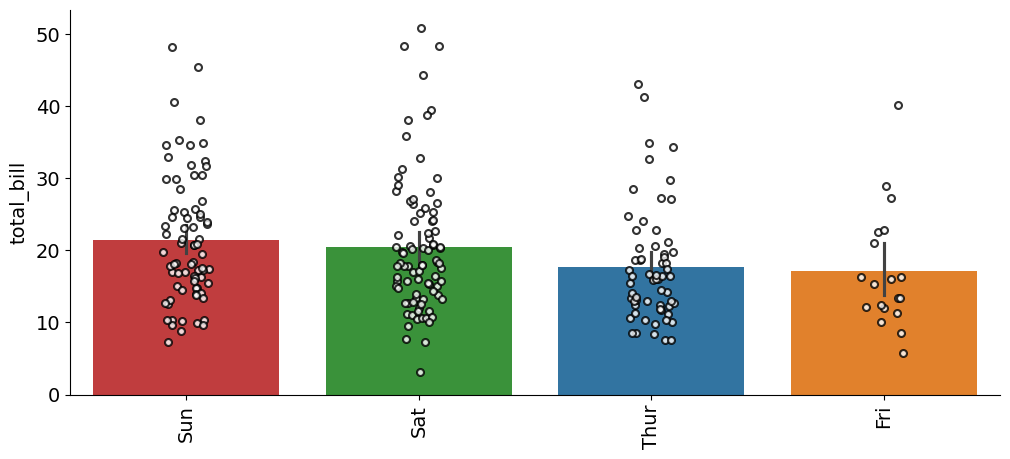

In [ ]:
plot_bar(df, value='total_bill', group='day')

In [ ]:
#| export
@delegates(sns.barplot)
def plot_group_bar(
    df: pd.DataFrame,  # wide-form dataframe
    value_cols: list[str],  # numeric columns to melt into grouped bars
    group: str,  # grouping column preserved during melt
    figsize: tuple[float, float] = (12, 5),  # figure size in inches
    order=None,  # optional x order passed to seaborn
    title: str | None = None,  # optional plot title
    fontsize: int = 14,  # axis label and tick size
    rotation: float = 90,  # x tick rotation angle
    **kwargs,  # forwarded barplot kwargs
):
    "Plot grouped bars after melting multiple value columns." 
    df_melted = df.melt(id_vars=group, value_vars=value_cols, var_name='Ranking', value_name='Value')
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df_melted,
        x=group,
        y='Value',
        hue='Ranking',
        order=order,
        capsize=0.1,
        err_kws={'linewidth': 1.5, 'color': 'gray'},
        alpha=1.0,
        ax=ax,
        **kwargs,
    )
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_xlabel('')
    ax.set_ylabel('Value', fontsize=fontsize)
    plt.xticks(rotation=rotation)
    if title is not None:
        plt.title(title, fontsize=fontsize)
    ax.spines[['right', 'top']].set_visible(False)
    plt.legend(fontsize=fontsize, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    return ax

<Axes: ylabel='Value'>

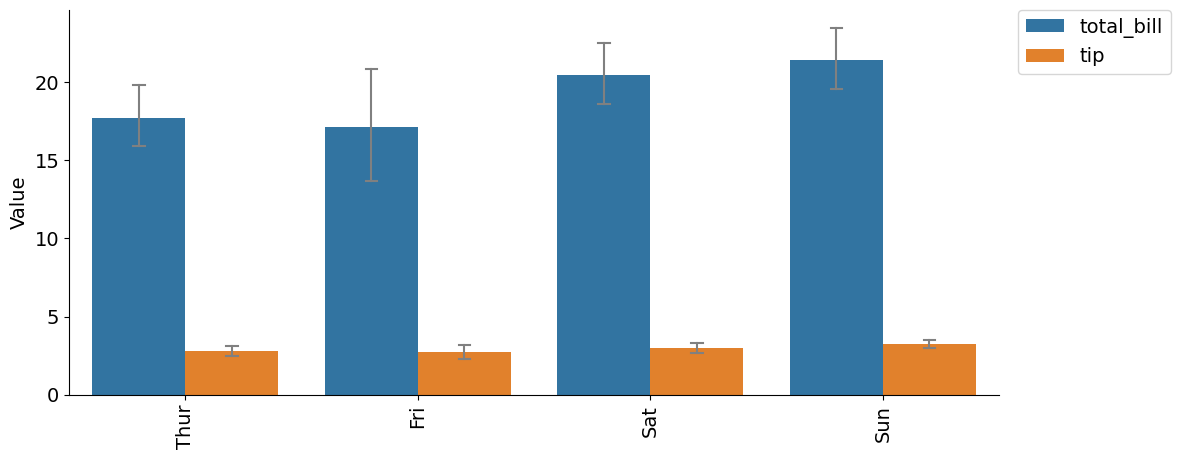

In [ ]:
plot_group_bar(df, value_cols=['total_bill', 'tip'], group='day')

In [ ]:
#| export
def plot_stacked(
    df: pd.DataFrame,  # dataframe containing the stacked categories
    group: str,  # x-axis categorical column
    hue: str,  # stacked hue column
    figsize: tuple[float, float] = (5, 4),  # figure size in inches
    xlabel: str | None = None,  # x-axis label override
    ylabel: str | None = None,  # y-axis label override
    add_value: bool = True,  # whether to annotate total counts
    **kwargs,  # forwarded histplot kwargs
):
    "Plot stacked counts for a categorical column."
    order = kwargs.pop('order', None)
    plot_df = df.copy()
    if order is not None:
        plot_df[group] = pd.Categorical(plot_df[group], categories=order, ordered=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=plot_df, x=group, hue=hue, multiple='stack', discrete=True, shrink=0.8, alpha=1.0, ax=ax, **kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if add_value:
        display_order = list(order) if order is not None else [tick.get_text() for tick in ax.get_xticklabels()]
        total_counts = df[group].value_counts()
        for idx, label in enumerate(display_order):
            count = int(total_counts.get(label, 0))
            ax.text(idx, count + 1, str(count), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    return ax

<Axes: >

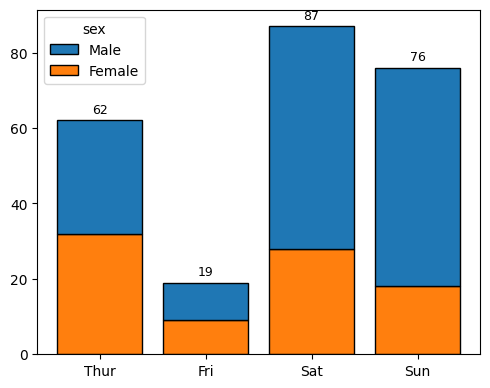

In [ ]:
plot_stacked(df, group='day', hue='sex')

## Distribution Comparisons

In [ ]:
#| export
def plot_violin(
    df: pd.DataFrame,  # long-form dataframe with value and group columns
    value: str = 'value',  # numeric column name
    group: str = 'variable',  # grouping column name
    ylabel: str | None = None,  # optional y-axis label override
    dots: bool = True,  # whether to overlay strip dots
    figsize: tuple[float, float] = (5, 3),  # figure size in inches
    **kwargs,  # forwarded violinplot kwargs
):
    "Plot violin plots with optional strip dots." 
    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(data=df, x=group, y=value, inner='box', linewidth=1, cut=0, bw_adjust=0.7, hue=group, dodge=False, legend=False, ax=ax, **kwargs)
    if dots:
        sns.stripplot(data=df, x=group, y=value, color='k', size=2, jitter=0.1, alpha=0.6, ax=ax)
    ax.set_xlabel('')
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    return ax

<Axes: ylabel='value'>

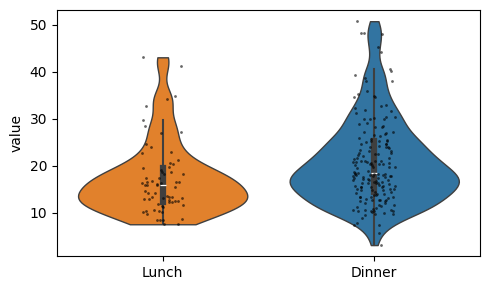

In [ ]:
df2 = df[['time', 'total_bill']].rename(columns={'time': 'variable', 'total_bill': 'value'})
plot_violin(df2)

In [ ]:
#| export
@delegates(sns.boxplot)
def plot_box(
    df: pd.DataFrame,  # long-form dataframe
    value: str,  # numeric column name
    group: str,  # grouping column name
    title: str | None = None,  # optional plot title
    figsize: tuple[float, float] = (6, 3),  # figure size in inches
    fontsize: int = 14,  # axis label and tick size
    dots: bool = True,  # whether to overlay strip dots
    rotation: float = 90,  # x tick rotation angle
    **kwargs,  # forwarded boxplot kwargs
):
    "Plot a box plot ordered by the group median." 
    fig, ax = plt.subplots(figsize=figsize)
    idx = df[[group, value]].groupby(group).median().sort_values(value, ascending=False).index
    sns.boxplot(data=df, x=group, y=value, order=idx, hue=group, dodge=False, legend=False, ax=ax, **kwargs)
    if dots:
        sns.stripplot(x=group, y=value, data=df, order=idx, jitter=True, color='black', size=3, ax=ax)
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_xlabel('')
    ax.set_ylabel(value, fontsize=fontsize)
    plt.xticks(rotation=rotation)
    if title is not None:
        plt.title(title, fontsize=fontsize)
    return ax

<Axes: ylabel='total_bill'>

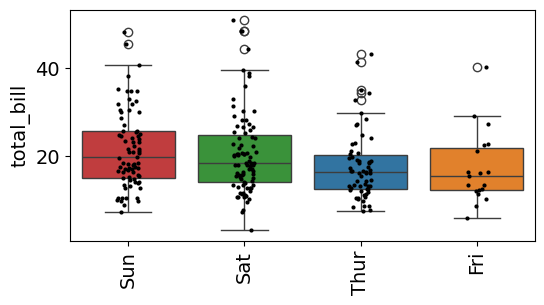

In [ ]:
plot_box(df, value='total_bill', group='day')

## Pie And Count Labels

In [ ]:
#| export
def plot_pie(
    value_counts: pd.Series,  # categorical counts
    hue_order: list[str] | None = None,  # explicit slice order
    labeldistance: float = 0.8,  # distance of labels from the center
    fontsize: int = 12,  # label font size
    font_color: str = 'black',  # label font color
    palette: str = 'tab20',  # seaborn palette name
    figsize: tuple[float, float] = (4, 3),  # figure size in inches
):
    "Plot a pie chart from a value-count series." 
    if hue_order is not None:
        value_counts = value_counts.reindex(hue_order)
    colors = sns.color_palette(palette, n_colors=len(value_counts))
    ax = value_counts.plot.pie(
        autopct='%1.1f%%',
        labeldistance=labeldistance,
        textprops={'fontsize': fontsize, 'color': font_color},
        colors=colors,
        figsize=figsize,
    )
    plt.ylabel('')
    plt.title(f'n={value_counts.sum():,}')
    return ax

<Axes: title={'center': 'n=244'}>

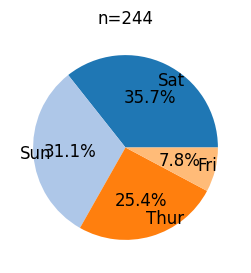

In [ ]:
plot_pie(df['day'].value_counts())

In [ ]:
#| export
def plot_cnt(
    cnt: pd.Series,  # output of df[col].value_counts()
    xlabel: str | None = None,  # x-axis label override
    ylabel: str = 'Count',  # y-axis label override
    figsize: tuple[float, float] = (6, 3),  # figure size in inches
):
    "Plot vertical counts with labels above the bars." 
    fig, ax = plt.subplots(figsize=figsize)
    cnt.plot.bar(ax=ax)
    for idx, value in enumerate(cnt):
        ax.text(idx, value + 0.5, f'{value:,}', ha='center', va='bottom', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    return ax

<Axes: ylabel='Count'>

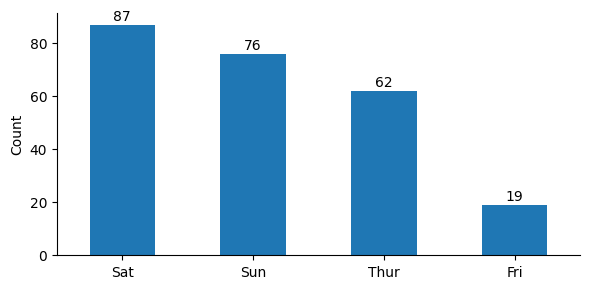

In [ ]:
plot_cnt(df['day'].value_counts())

## Composition

In [ ]:
#| export
def calculate_pct(
    df: pd.DataFrame,  # source dataframe
    bin_col: str,  # binned x-axis column
    hue_col: str,  # stacked hue column
) -> pd.DataFrame:
    "Calculate within-bin percentages for a stacked composition chart."
    count_df = df.groupby([bin_col, hue_col], observed=False).size().unstack(fill_value=0)
    pct_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
    return pct_df

In [ ]:
df2 = sns.load_dataset('titanic').dropna(subset=['class', 'sex']).reset_index(drop=True)
calculate_pct(df2, 'class', 'sex')

sex,female,male
class,,
First,43.518519,56.481481
Second,41.304348,58.695652
Third,29.327902,70.672098


In [ ]:
#| export
def plot_composition(
    df: pd.DataFrame,  # source dataframe
    bin_col: str,  # binned x-axis column
    hue_col: str,  # stacked hue column
    palette: dict | list | str = 'tab20',  # colors passed to get_plt_color
    legend_title: str | None = None,  # legend title override
    rotation: float = 45,  # x tick rotation angle
    xlabel: str | None = None,  # x-axis label override
    ylabel: str = 'Percentage',  # y-axis label override
    figsize: tuple[float, float] = (5, 3),  # figure size in inches
):
    "Plot stacked percentages for a bin-by-category composition."
    pct_df = calculate_pct(df, bin_col, hue_col)
    colors = get_plt_color(palette, list(pct_df.columns))
    ax = pct_df.plot(kind='bar', figsize=figsize, stacked=True, color=colors)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.xticks(rotation=rotation)
    plt.legend(title=legend_title or hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    return ax

<Axes: ylabel='Percentage'>

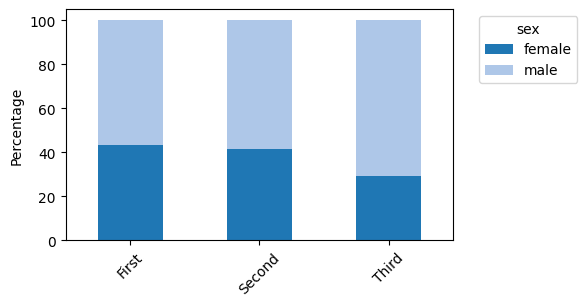

In [ ]:
plot_composition(df2, 'class', 'sex')

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()